In [1]:
# %matplotlib widget

import os
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import shap
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import fdrcorrection

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import make_scorer, precision_score, recall_score, classification_report, ConfusionMatrixDisplay, f1_score, make_scorer, RocCurveDisplay
from itertools import combinations

def precision_class_0(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[0]

def precision_class_1(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[1]

def recall_class_0(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[0]

def recall_class_1(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[1]

import warnings
import anndata
import scanpy as sc


7033aa132a2e31989f4d19b022da42a30bb28bcea09f6282

In [2]:
os.getcwd()

'/workspace/paper/ML/XAI'

In [3]:
os.chdir("../Store/PBMC_BCELLS_2DATASET")
os.getcwd()

'/workspace/paper/ML/Store/PBMC_BCELLS_2DATASET'

<h2>Dataset Upload</h2>

In [4]:
dataset = sc.read_h5ad("./datasetDeclustered.h5ad")
label = dataset.obs['condition']
dataset

AnnData object with n_obs × n_vars = 3505 × 17410
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting', 'dataset', 'generalized_celltype', '_scvi_batch', '_scvi_labels', 'concat_batch'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'dataset_colors', 'generalized_celltype_colors', 'majority_voting_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'corrected_latent', 'latent'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

<h3>Scaling</h3>

In [5]:
import joblib
import numpy as np
import anndata
# Assume 'dataset' is your loaded AnnData object

# --- 1. Load Model and Scale the Entire Dataset ---
print("Loading the refit model...")
gradientBoosting = joblib.load("BestModelRefittedWholeDataset.pkl")

print("Scaling the entire dataset.X using the model's scaler...")
# Keep the original data if needed elsewhere, otherwise you could scale in place
# current = dataset.X.copy() # Keep if you need the original unscaled data later

dataset_x = pd.DataFrame(dataset.X, columns=dataset.var_names)
current_Scaled = gradientBoosting[0].transform(dataset_x) # Scale the data

# Update the original dataset's .X attribute with the scaled matrix
# Now, 'dataset' contains the fully scaled data for ALL samples
dataset.X = current_Scaled
print(
    "Dataset.X updated with scaled data. Shape:", dataset.X.shape
)
# Check the max value in the scaled data (should be <= 1 for MinMaxScaler)
print("Max value in scaled dataset.X:", np.max(dataset.X)) # Use np.max()

# --- 2. Prepare for Sampling ---
# Calculate the number of samples per condition (10% of total)
n = int(dataset.shape[0] * 0.1)
print(f"Target number of samples per condition: {n}")

# Define a random seed
random_seed = 42 # You can choose any integer

# Create a RandomState object
rng = np.random.RandomState(random_seed)

# Get indices for each condition from the dataset's metadata
ms_indices = dataset.obs.index[dataset.obs['condition'] == 'MS']
ctrl_indices = dataset.obs.index[dataset.obs['condition'] == 'CTRL']

# Ensure n is not larger than the smallest group size
n_ms = len(ms_indices)
n_ctrl = len(ctrl_indices)
if n > min(n_ms, n_ctrl):
    print(
        f"Warning: Requested n ({n}) is larger than the smallest group size "
        f"(MS: {n_ms}, CTRL: {n_ctrl}). Clamping n to {min(n_ms, n_ctrl)}."
    )
    n = min(n_ms, n_ctrl)
    print(f"Adjusted number of samples per condition: {n}")


print("Sampling indices for each condition...")

# Define a random state
random_seed = 42 # You can choose any integer

# Sample n indices randomly without replacement from each group
# Set the random_state parameter for reproducibility
sampled_ms_indices = np.random.choice(
    ms_indices, size=n, replace=False
)
sampled_ctrl_indices = np.random.choice(
    ctrl_indices, size=n, replace=False
)


print(
    f"Selected {len(sampled_ms_indices)} MS indices and "
    f"{len(sampled_ctrl_indices)} CTRL indices."
)

# Combine the sampled indices
combined_indices = np.concatenate([sampled_ms_indices, sampled_ctrl_indices])

# Create the new AnnData object 'adata_sampled' by slicing the *original*
# 'dataset'. Since 'dataset.X' was already updated with scaled data,
# 'adata_sampled' will contain the corresponding scaled data for the
# selected samples.
print("Creating subsampled AnnData object...")
adata_sampled_combined = dataset[combined_indices, :].copy() # Use .copy()

# --- 4. Shuffle the Subsampled AnnData ---
print("Shuffling the subsampled AnnData object...")
# Shuffle the order of observations within the sampled data
shuffled_order = np.random.permutation(adata_sampled_combined.n_obs)
adata_sampled = adata_sampled_combined[shuffled_order, :].copy() # Use .copy() again

# --- 5. Final Check ---
print("\n--- Final State ---")
print("Original 'dataset' (contains ALL samples, scaled):")
print(dataset)
# Verify max value again if needed: print(np.max(dataset.X))

print("\nSubsampled 'adata_sampled' (contains only sampled data, scaled):")
print(adata_sampled)
# Verify max value in sampled data: print(np.max(adata_sampled.X))
# Verify conditions in sampled data: print(adata_sampled.obs['condition'].value_counts())



Loading the refit model...


/opt/venv/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/lib/python3.10/pickle.py:1718: UserWarning: [14:40:51] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
/opt/venv/lib/python3.10/site-packages/sklearn/base.py:442:

Scaling the entire dataset.X using the model's scaler...
Dataset.X updated with scaled data. Shape: (3505, 17410)
Max value in scaled dataset.X: 1.0000001
Target number of samples per condition: 350
Sampling indices for each condition...
Selected 350 MS indices and 350 CTRL indices.
Creating subsampled AnnData object...
Shuffling the subsampled AnnData object...

--- Final State ---
Original 'dataset' (contains ALL samples, scaled):
AnnData object with n_obs × n_vars = 3505 × 17410
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting', 'dataset', 'generalized_celltype', '_scvi_batch', '_scvi_labels', 'concat_batch'
    uns: '_scvi_manager_uuid', '_scvi_u

<h2> SHAP Explanations</h3>

In [6]:
import shap
import numpy as np
import pandas as pd

# --- Prerequisites ---
# gradientBoosting, dataset, adata_sampled are loaded and prepared

# --- Run the Original SHAP Calculation (as you did) ---
print("Initializing SHAP TreeExplainer...")
final_model = gradientBoosting[-1]
background_data = adata_sampled.X
background_data = pd.DataFrame(adata_sampled.X, columns = adata_sampled.var_names)
explainer = shap.TreeExplainer(final_model, background_data)


dataset_pd = pd.DataFrame(dataset.X, columns=dataset.var_names)
print(f"Calculating SHAP values for the entire dataset ({dataset.n_obs} samples)...")
shap_object = explainer(dataset_pd)
shap_values = shap_object.values

if isinstance(shap_values, list):
    print("Detected multi-class output (list). Averaging importance across classes.")
    shap_importance = np.mean([np.abs(v).mean(0) for v in shap_values], axis=0)
elif shap_values.ndim == 3:
    print("Detected multi-class output (3D array). Averaging importance across classes.")
    shap_importance = np.abs(shap_values).mean(0).mean(1)
else:
    print("Detected regression or binary classification output (2D array).")
    shap_importance = np.abs(shap_values).mean(0)

print("Calculated global feature importance (mean absolute SHAP value).")

# --- Get Feature Names (Robustly) ---
try:
    feature_names = gradientBoosting.feature_names_in_
    if len(feature_names) != shap_importance.shape[0]:
         raise ValueError("Mismatch: feature_names_in_ vs SHAP dimensions.")
except AttributeError:
    print("Warning: Could not get 'feature_names_in_' from the model.")
    print("Attempting to use dataset.var_names as feature names.")
    if dataset.n_vars == shap_importance.shape[0]:
        feature_names = dataset.var_names.tolist()
    else:
        print(f"Error: SHAP features ({shap_importance.shape[0]}) != dataset vars ({dataset.n_vars}).")
        feature_names = [f"feature_{i}" for i in range(shap_importance.shape[0])]

# --- Create SHAP Importance DataFrame ---
print("Creating Pandas DataFrame for SHAP feature importance...")
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'MeanAbsoluteShap': shap_importance
})
feature_importance_df = feature_importance_df.sort_values(
    by='MeanAbsoluteShap', ascending=False
).reset_index(drop=True)
print("Sorted SHAP feature importance DataFrame created.")
print("\nTop SHAP Feature Importances:")
print(feature_importance_df.head(20))
print(f"\nNumber of features with Zero SHAP importance: {(feature_importance_df['MeanAbsoluteShap'] == 0).sum()}")
print(f"Total features: {len(feature_importance_df)}")


# --- DIAGNOSTIC STEP 1: Check Model's Internal Importance ---
print("\n--- DIAGNOSTICS ---")
if hasattr(final_model, 'feature_importances_'):
    print("Checking model's internal feature_importances_...")
    model_importance = final_model.feature_importances_
    if len(model_importance) == len(feature_names):
        model_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'ModelImportance': model_importance
        })
        model_importance_df = model_importance_df.sort_values(
            by='ModelImportance', ascending=False
        ).reset_index(drop=True)

        print("\nModel's Internal Feature Importance (Top 20):")
        print(model_importance_df.head(20))
        zero_model_importance_count = (model_importance_df['ModelImportance'] == 0).sum()
        print(f"\nNumber of features with Zero Model importance: {zero_model_importance_count}")

        # Compare zero importance features
        zero_shap_features = set(feature_importance_df[feature_importance_df['MeanAbsoluteShap'] == 0]['Feature'])
        zero_model_features = set(model_importance_df[model_importance_df['ModelImportance'] == 0]['Feature'])
        if zero_shap_features == zero_model_features:
            print("\n>>>>> The features with zero SHAP importance match the features with zero internal model importance. <<<<<")
            print(">>>>> This suggests SHAP is correctly reflecting the model, and the issue lies in the model training/parameters. <<<<<")
        else:
            print("\n>>>>> Mismatch between zero SHAP features and zero model importance features. This might indicate a SHAP calculation issue (e.g., background data). <<<<<")
            print(f"Features zero in SHAP but not model: {len(zero_shap_features - zero_model_features)}")
            print(f"Features zero in model but not SHAP: {len(zero_model_features - zero_shap_features)}")

    else:
        print("Warning: Mismatch between number of model importances and feature names.")
else:
    print("Model does not have a 'feature_importances_' attribute.")

# --- DIAGNOSTIC STEP 2: Check Model Parameters ---
print("\nGradient Boosting Model Parameters:")
try:
    print(final_model.get_params())
    # Look specifically at: max_depth, min_samples_leaf, min_samples_split, max_features
except AttributeError:
    print("Could not get model parameters using get_params().")

# --- Save the SHAP objects ---
print("\nSaving SHAP objects...")
try:
    joblib.dump(shap_object, "xgbPBMCBCELLS shapexplainer.pkl")
    print("Saved shap_object to xgbPBMCBCELLS shapexplainer.pkl")
except Exception as e:
    print(f"Error saving shap_object: {e}")

# You mentioned saving 'expl_sorted', but your code doesn't create this.
# Assuming you might want to save the sorted feature importance DataFrame:
try:
    joblib.dump(feature_importance_df, "xgbPBMCBCELLS_feature_importance.pkl")
    print("Saved sorted feature_importance_df to xgbPBMCBCELLS_feature_importance.pkl")
except Exception as e:
    print(f"Error saving feature_importance_df: {e}")


Initializing SHAP TreeExplainer...


ValueError: could not convert string to float: '[6.0361296E-1]'

In [7]:
from collections import defaultdict

def addGeneClusters(geneDict, clusters):
    clusters = invertDict(clusters)
    resultValues = list(geneDict.values())
    resultKeys = list(geneDict.keys())

    for gene, cluster in clusters.items():
        if gene in list(geneDict.keys()):
            print(gene, len(cluster), cluster)
            insertGenes = list(set(cluster) - set([gene]))
            idx = resultKeys.index(gene)
            resultValues[idx+1:idx+1] = [resultValues[idx]] * len(insertGenes)
            resultKeys[idx+1:idx+1] = insertGenes

    return dict(zip(resultKeys, resultValues))

def invertDict(d):
    inverted = defaultdict(list)

    for keys_tuple, value in d.items():
        inverted[value].extend(list(keys_tuple))

    return dict(inverted)

shap_object = joblib.load("xgbPBMCBCELLS shapexplainer.pkl")
expl_sorted = joblib.load("xgbPBMCBCELLS_feature_importance.pkl")
expl_sorted = expl_sorted.set_index('Feature')['MeanAbsoluteShap'].to_dict()
feature_nonZero = {k:v for k, v in expl_sorted.items() if v != 0}
print(len(feature_nonZero))

96


Features with non-zero importance

In [8]:
print(list(feature_nonZero.keys()))

['SLC30A4', 'APBB2', 'AGPAT5', 'YBX3', 'EPHX3', 'APLP2', 'TSPAN13', 'LGR5', 'IGFBP4', 'CD200', 'LINC01374', 'FAM228A', 'FCER2', 'ADORA2B', 'CENPT', 'GADD45A', 'TTTY14', 'AC017074.2', 'MUC12', 'LPXN', 'ST14', 'STAMBPL1', 'ACR', 'IHH', 'IFNGR2', 'CD37', 'GFRA2', 'SERINC4', 'NLRC5', 'AC009227.2', 'FZD6', 'ZNF221', 'INTS3', 'VARS2', 'OR2L8', 'LINC00330', 'CPA2', 'ZCCHC18', 'FAM187B', 'SERTAD4-AS1', 'XPO6', 'MIR1-1HG', 'MARCH9', 'GPNMB', 'ARHGAP42', 'ZC3HAV1', 'OR4P4', 'OR2L3', 'LGALS4', 'PCAT14', 'ZBTB20-AS3', 'ZNF850', 'SGCZ', 'SNN', 'LRRTM2', 'SYVN1', 'ALPL', 'COL10A1', 'ADAMDEC1', 'CD79B', 'AC018832.1', 'C10orf88', 'PCSK1', 'NFATC2', 'MTRNR2L12', 'VPS37C', 'ZNF345', 'PLPPR4', 'INAFM1', 'UBB', 'EQTN', 'DLX6-AS1', 'IL10RA', 'CCNJ', 'PLBD1', 'BMP2', 'RTBDN', 'SHBG', 'ADAM21', 'MAGEB2', 'HOXB2', 'EHHADH', 'DIMT1', 'FAM186A', 'CCDC169', 'SAMSN1-AS1', 'HNRNPA0', 'KRT10', 'RCE1', 'FAM120B', 'PAX6', 'C3', 'EPN1', 'TM4SF18', 'SMIM3', 'STOX1']


<h2>Explorative Graphs</h2>

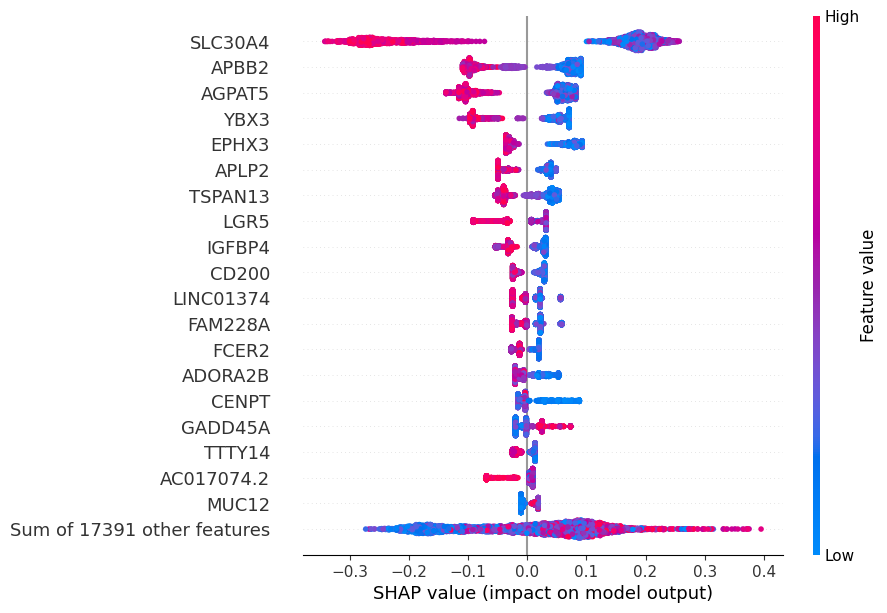

In [9]:
plt.close()
fig, ax = plt.subplots()
shap.plots.beeswarm(shap_object, max_display=20, plot_size=(10, 7), show=False)
fig.subplots_adjust(left=0.3)

Text(0.5, 1.0, 'Top 25 features for importance')

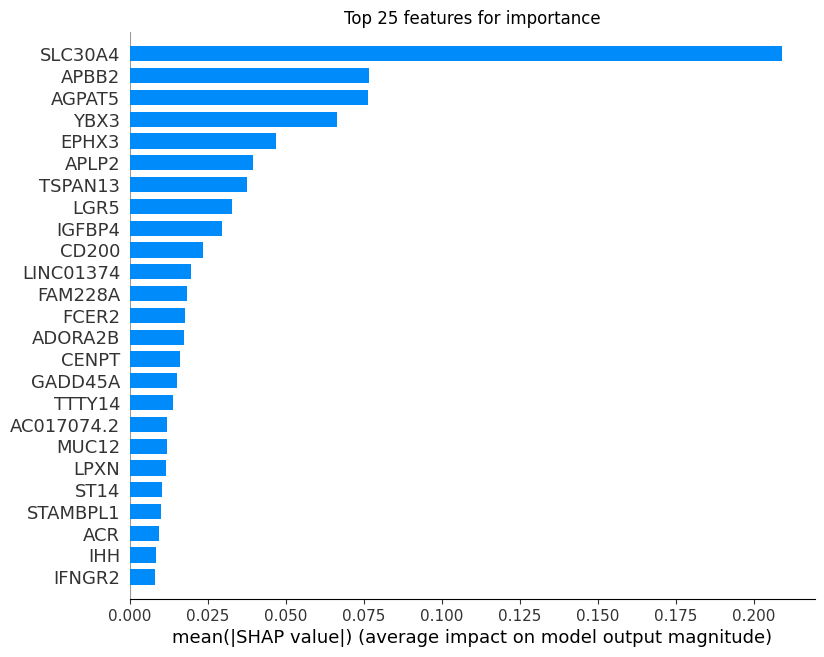

In [10]:
plt.close()
fig, ax = plt.subplots()
shap.summary_plot(shap_object, current_Scaled, max_display=25, plot_type="bar", show=False, plot_size=(10, 7))
fig.subplots_adjust(left=0.3, top=0.9)
plt.title('Top 25 features for importance')

In [11]:
cont = 0
for value in expl_sorted.values():
      if value != 0:
        cont+=1

print('Feature con importanza non zero:', cont)

Feature con importanza non zero: 96


<h3>Distribution of feature importances</h3>

Mean: 0.010805013303190109
Stadnard Deviation: 0.024997559985644333
Number of features of 0 sigma: 20 ['SLC30A4', 'APBB2', 'AGPAT5', 'YBX3', 'EPHX3', 'APLP2', 'TSPAN13', 'LGR5', 'IGFBP4', 'CD200', 'LINC01374', 'FAM228A', 'FCER2', 'ADORA2B', 'CENPT', 'GADD45A', 'TTTY14', 'AC017074.2', 'MUC12', 'LPXN']


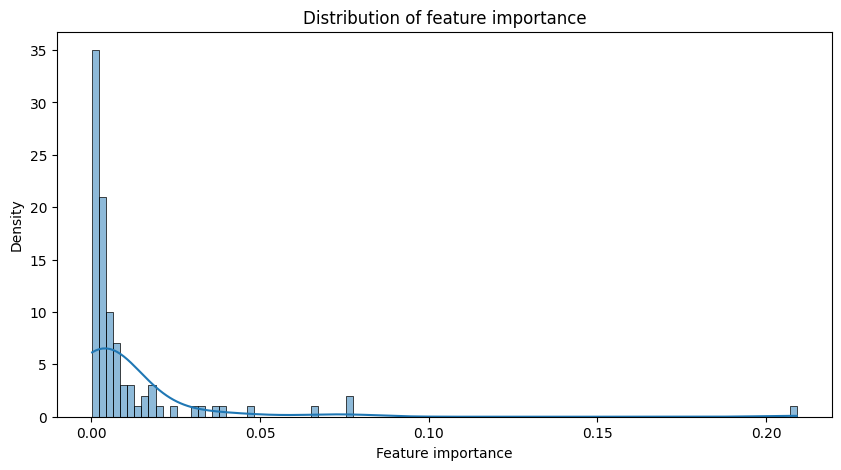

In [12]:
non_zeroShap = [value for value in expl_sorted.values() if value != 0]
mean = np.mean(non_zeroShap)
std = np.std(non_zeroShap)

print('Mean:', mean)
print('Stadnard Deviation:', std)
k=0
bestFeatures = [key for key, value in expl_sorted.items() if value > (k*std)+mean]
print(f"Number of features of {k} sigma:", len(bestFeatures), bestFeatures)

plt.close()
plt.figure(figsize=(10,5))
sns.histplot(data=non_zeroShap, bins=100, kde=True)
plt.title('Distribution of feature importance')
plt.xlabel('Feature importance')
plt.ylabel('Density')
plt.show()

<h3>Cumulative Importance</h3>

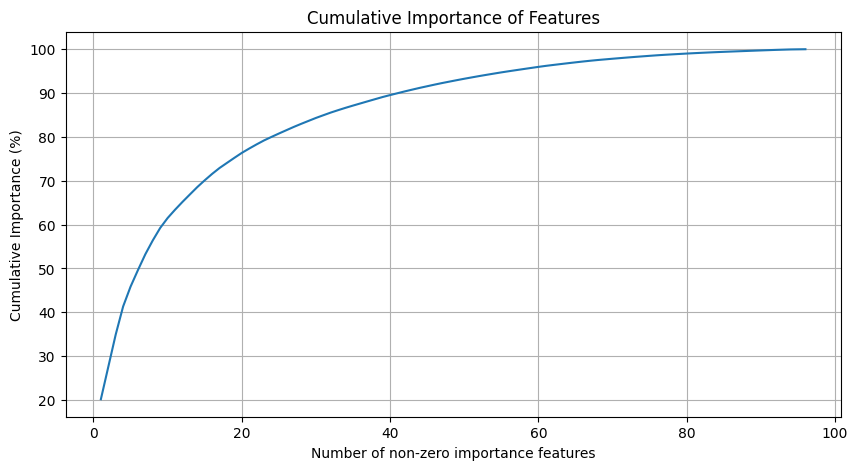

In [13]:
cumulativeImportance = (np.array(list(feature_nonZero.values())).cumsum() / np.array(list(feature_nonZero.values())).sum()) * 100

plt.close()
plt.figure(figsize=(10,5))
plt.plot(range(1, len(cumulativeImportance)+1), cumulativeImportance)
plt.xlabel('Number of non-zero importance features')
plt.ylabel('Cumulative Importance (%)')
plt.title('Cumulative Importance of Features')
plt.grid()
plt.show()

In [14]:
print(list(feature_nonZero.keys())[:25])

['SLC30A4', 'APBB2', 'AGPAT5', 'YBX3', 'EPHX3', 'APLP2', 'TSPAN13', 'LGR5', 'IGFBP4', 'CD200', 'LINC01374', 'FAM228A', 'FCER2', 'ADORA2B', 'CENPT', 'GADD45A', 'TTTY14', 'AC017074.2', 'MUC12', 'LPXN', 'ST14', 'STAMBPL1', 'ACR', 'IHH', 'IFNGR2']


<h3>Bar plot of importances over the two classes</h3>

In [15]:
current = dataset_x

current["Label"] = dataset.obs["condition"].values


cohorts = ["MS" if label == "MS" else "CTRL" for label in current['Label']]
cohort_explanation = shap_object.cohorts(cohorts)
cohort_means = cohort_explanation.abs.mean(0)

cohort_df = pd.DataFrame({
    'MS': cohort_explanation.cohorts['MS'].values.mean(0),
    'CTRL': cohort_explanation.cohorts['CTRL'].values.mean(0)
}, index=dataset.var_names) 

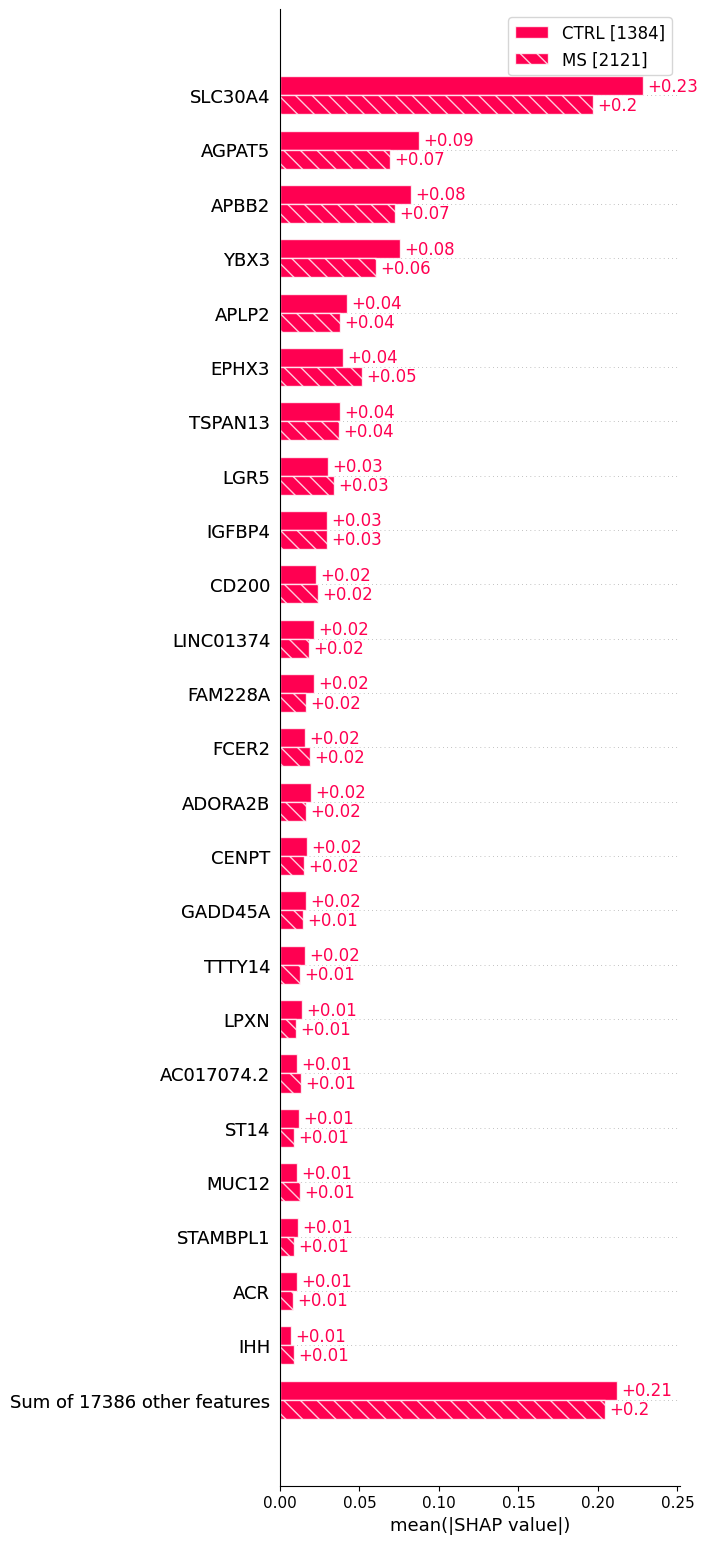

In [16]:
plt.close()
fig, ax = plt.subplots(figsize=(10, 5))
shap.plots.bar(cohort_means, max_display=25, show=False)
fig.subplots_adjust(left=0.4)

Showing the genes where the importance for the class MS is higher than a value epsilon compared to the importance of the Control class

In [17]:
diff = np.abs(cohort_df['MS'] - cohort_df['CTRL'])

Difference importance between classes distribution

In [18]:
diff_mean = np.mean(diff)
diff_meadian = np.median(diff)
diff_std = np.std(diff)

print('Mean:', diff_mean)
print('Median:', diff_meadian)
print('Stadnard Deviation:', diff_std)
k=0
bestFeatures = [key for key, value in expl_sorted.items() if value > (k*diff_std)+diff_mean]
print(f"Number of features over {k} sigma:", len(bestFeatures), bestFeatures)

Mean: 4.6163828581381274e-05
Median: 0.0
Stadnard Deviation: 0.0018309576126529033
Number of features over 0 sigma: 96 ['SLC30A4', 'APBB2', 'AGPAT5', 'YBX3', 'EPHX3', 'APLP2', 'TSPAN13', 'LGR5', 'IGFBP4', 'CD200', 'LINC01374', 'FAM228A', 'FCER2', 'ADORA2B', 'CENPT', 'GADD45A', 'TTTY14', 'AC017074.2', 'MUC12', 'LPXN', 'ST14', 'STAMBPL1', 'ACR', 'IHH', 'IFNGR2', 'CD37', 'GFRA2', 'SERINC4', 'NLRC5', 'AC009227.2', 'FZD6', 'ZNF221', 'INTS3', 'VARS2', 'OR2L8', 'LINC00330', 'CPA2', 'ZCCHC18', 'FAM187B', 'SERTAD4-AS1', 'XPO6', 'MIR1-1HG', 'MARCH9', 'GPNMB', 'ARHGAP42', 'ZC3HAV1', 'OR4P4', 'OR2L3', 'LGALS4', 'PCAT14', 'ZBTB20-AS3', 'ZNF850', 'SGCZ', 'SNN', 'LRRTM2', 'SYVN1', 'ALPL', 'COL10A1', 'ADAMDEC1', 'CD79B', 'AC018832.1', 'C10orf88', 'PCSK1', 'NFATC2', 'MTRNR2L12', 'VPS37C', 'ZNF345', 'PLPPR4', 'INAFM1', 'UBB', 'EQTN', 'DLX6-AS1', 'IL10RA', 'CCNJ', 'PLBD1', 'BMP2', 'RTBDN', 'SHBG', 'ADAM21', 'MAGEB2', 'HOXB2', 'EHHADH', 'DIMT1', 'FAM186A', 'CCDC169', 'SAMSN1-AS1', 'HNRNPA0', 'KRT10', 'RCE

Test for difference of importance between classes

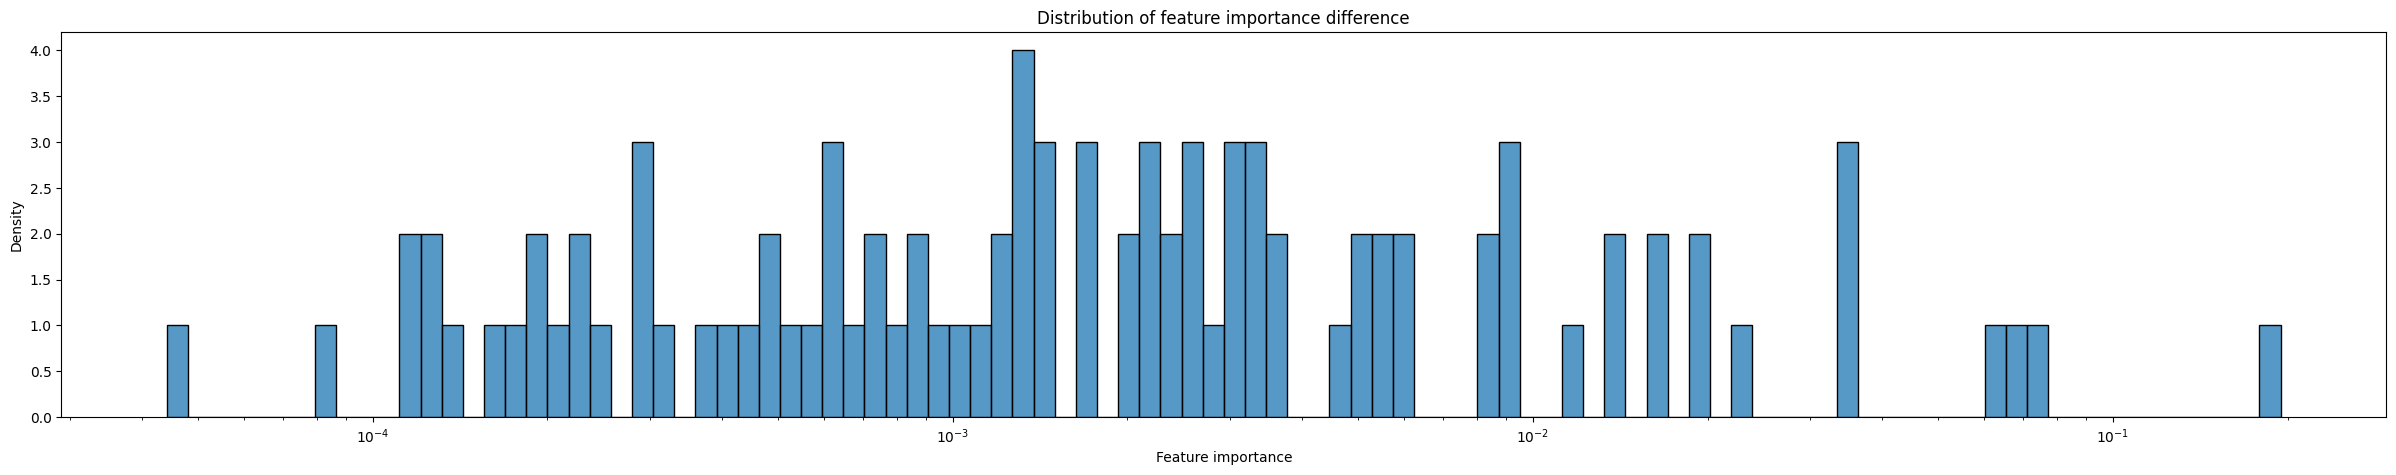

In [19]:
plt.close()
plt.figure(figsize=(30,5))
sns.histplot(data=diff, bins=100, log_scale=True)
plt.title('Distribution of feature importance difference')
plt.xlabel('Feature importance')
plt.ylabel('Density')
plt.show()

In [20]:
epsilon = 0.01  # Modifica questo valore
significant_features = diff[diff >= epsilon].index.tolist()

print(f"Feature con differenza >= {epsilon}:")
print(len(significant_features), significant_features)

Feature con differenza >= 0.01:
15 ['GADD45A', 'FAM228A', 'LINC01374', 'LGR5', 'SLC30A4', 'EPHX3', 'TTTY14', 'APBB2', 'IGFBP4', 'CD200', 'AGPAT5', 'APLP2', 'TSPAN13', 'FCER2', 'YBX3']


DEA between cohorts over SHAP values

In [23]:
warnings.filterwarnings("ignore")

current = dataset_x
current["Label"] = dataset.obs["condition"].values


cohorts = ["MS" if label == "MS" else "Control" for label in current['Label']]
cohort_explanation = shap_object.cohorts(cohorts)

cohort_ms = pd.DataFrame(cohort_explanation.cohorts['MS'].values, columns=dataset.var_names)
cohort_control = pd.DataFrame(cohort_explanation.cohorts['Control'].values, columns=dataset.var_names)

p_values = [mannwhitneyu(cohort_control[gene], cohort_ms[gene])[1] for gene in cohort_control.columns]
boolean, p_values_corrected = fdrcorrection(p_values, alpha=0.05)
deGenes = {gene:value for gene, sig, value in zip(cohort_control.columns, boolean, p_values_corrected) if sig}

print(len(deGenes), list(deGenes.keys()))

96 ['ALPL', 'GADD45A', 'PLPPR4', 'INTS3', 'SERTAD4-AS1', 'OR2L8', 'OR2L3', 'FAM228A', 'AC017074.2', 'AC009227.2', 'IHH', 'AC018832.1', 'MTRNR2L12', 'ZBTB20-AS3', 'TM4SF18', 'EHHADH', 'DIMT1', 'PCSK1', 'HNRNPA0', 'LRRTM2', 'VARS2', 'COL10A1', 'FAM120B', 'GPNMB', 'DLX6-AS1', 'MUC12', 'CPA2', 'ZC3HAV1', 'MAGEB2', 'ZCCHC18', 'SGCZ', 'GFRA2', 'ADAMDEC1', 'FZD6', 'EQTN', 'PAX6', 'OR4P4', 'LPXN', 'VPS37C', 'RCE1', 'ARHGAP42', 'ST14', 'STOX1', 'LINC01374', 'CCNJ', 'C10orf88', 'PLBD1', 'FAM186A', 'MARCH9', 'LGR5', 'CCDC169', 'LINC00330', 'ADAM21', 'SERINC4', 'SLC30A4', 'SNN', 'XPO6', 'NLRC5', 'CENPT', 'SHBG', 'ADORA2B', 'UBB', 'KRT10', 'HOXB2', 'CD79B', 'BMP2', 'NFATC2', 'MIR1-1HG', 'C3', 'RTBDN', 'EPHX3', 'FAM187B', 'ZNF850', 'ZNF345', 'LGALS4', 'ZNF221', 'INAFM1', 'TTTY14', 'PCAT14', 'ACR', 'SAMSN1-AS1', 'IFNGR2', 'IL10RA', 'SMIM3', 'STAMBPL1', 'APBB2', 'IGFBP4', 'EPN1', 'CD200', 'AGPAT5', 'APLP2', 'TSPAN13', 'FCER2', 'YBX3', 'SYVN1', 'CD37']


In [24]:
print(len(set(significant_features).intersection(set(deGenes.keys()))), set(significant_features).intersection(set(deGenes.keys())))

15 {'YBX3', 'FCER2', 'FAM228A', 'IGFBP4', 'AGPAT5', 'SLC30A4', 'LGR5', 'EPHX3', 'TSPAN13', 'GADD45A', 'TTTY14', 'APBB2', 'APLP2', 'CD200', 'LINC01374'}


<h3>Dependence plot with interactions for the 2 known gene of the family HLA</h3>

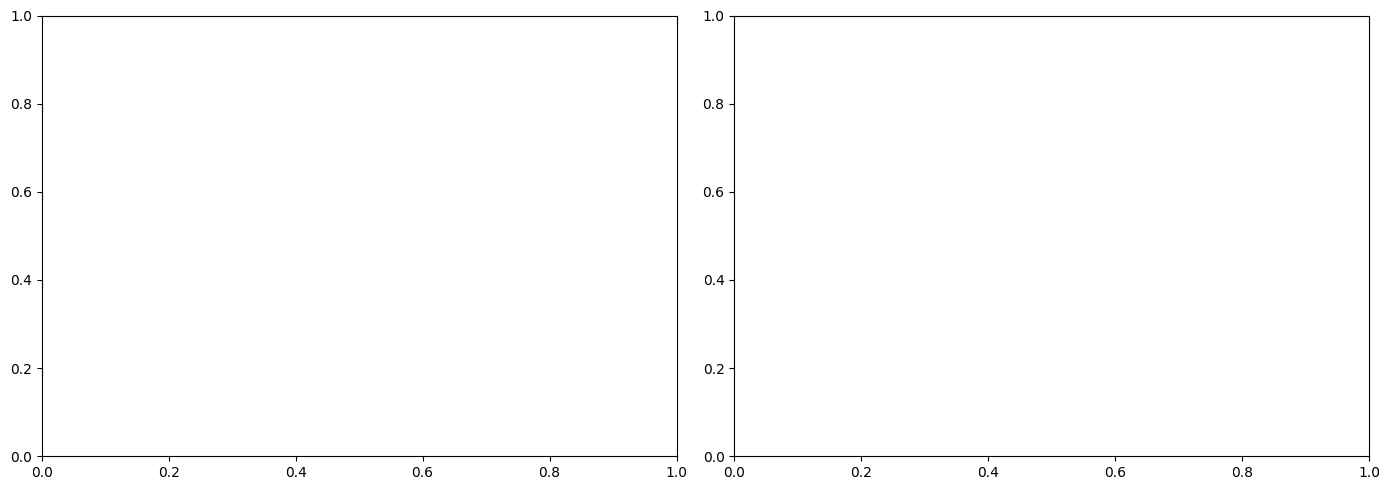

In [25]:
shap_values = shap_object.values

plt.close()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
#shap.dependence_plot("HLA-DRB1", shap_values, current_Scaled, show=False, interaction_index='HLA-DRB5', ax=ax[0])
#shap.dependence_plot("HLA-DRB5", shap_values, current_Scaled, show=False, interaction_index='HLA-DRB1', ax=ax[1])
plt.tight_layout()

<h3>Dependence plot of the first 20 features for importance</h3>

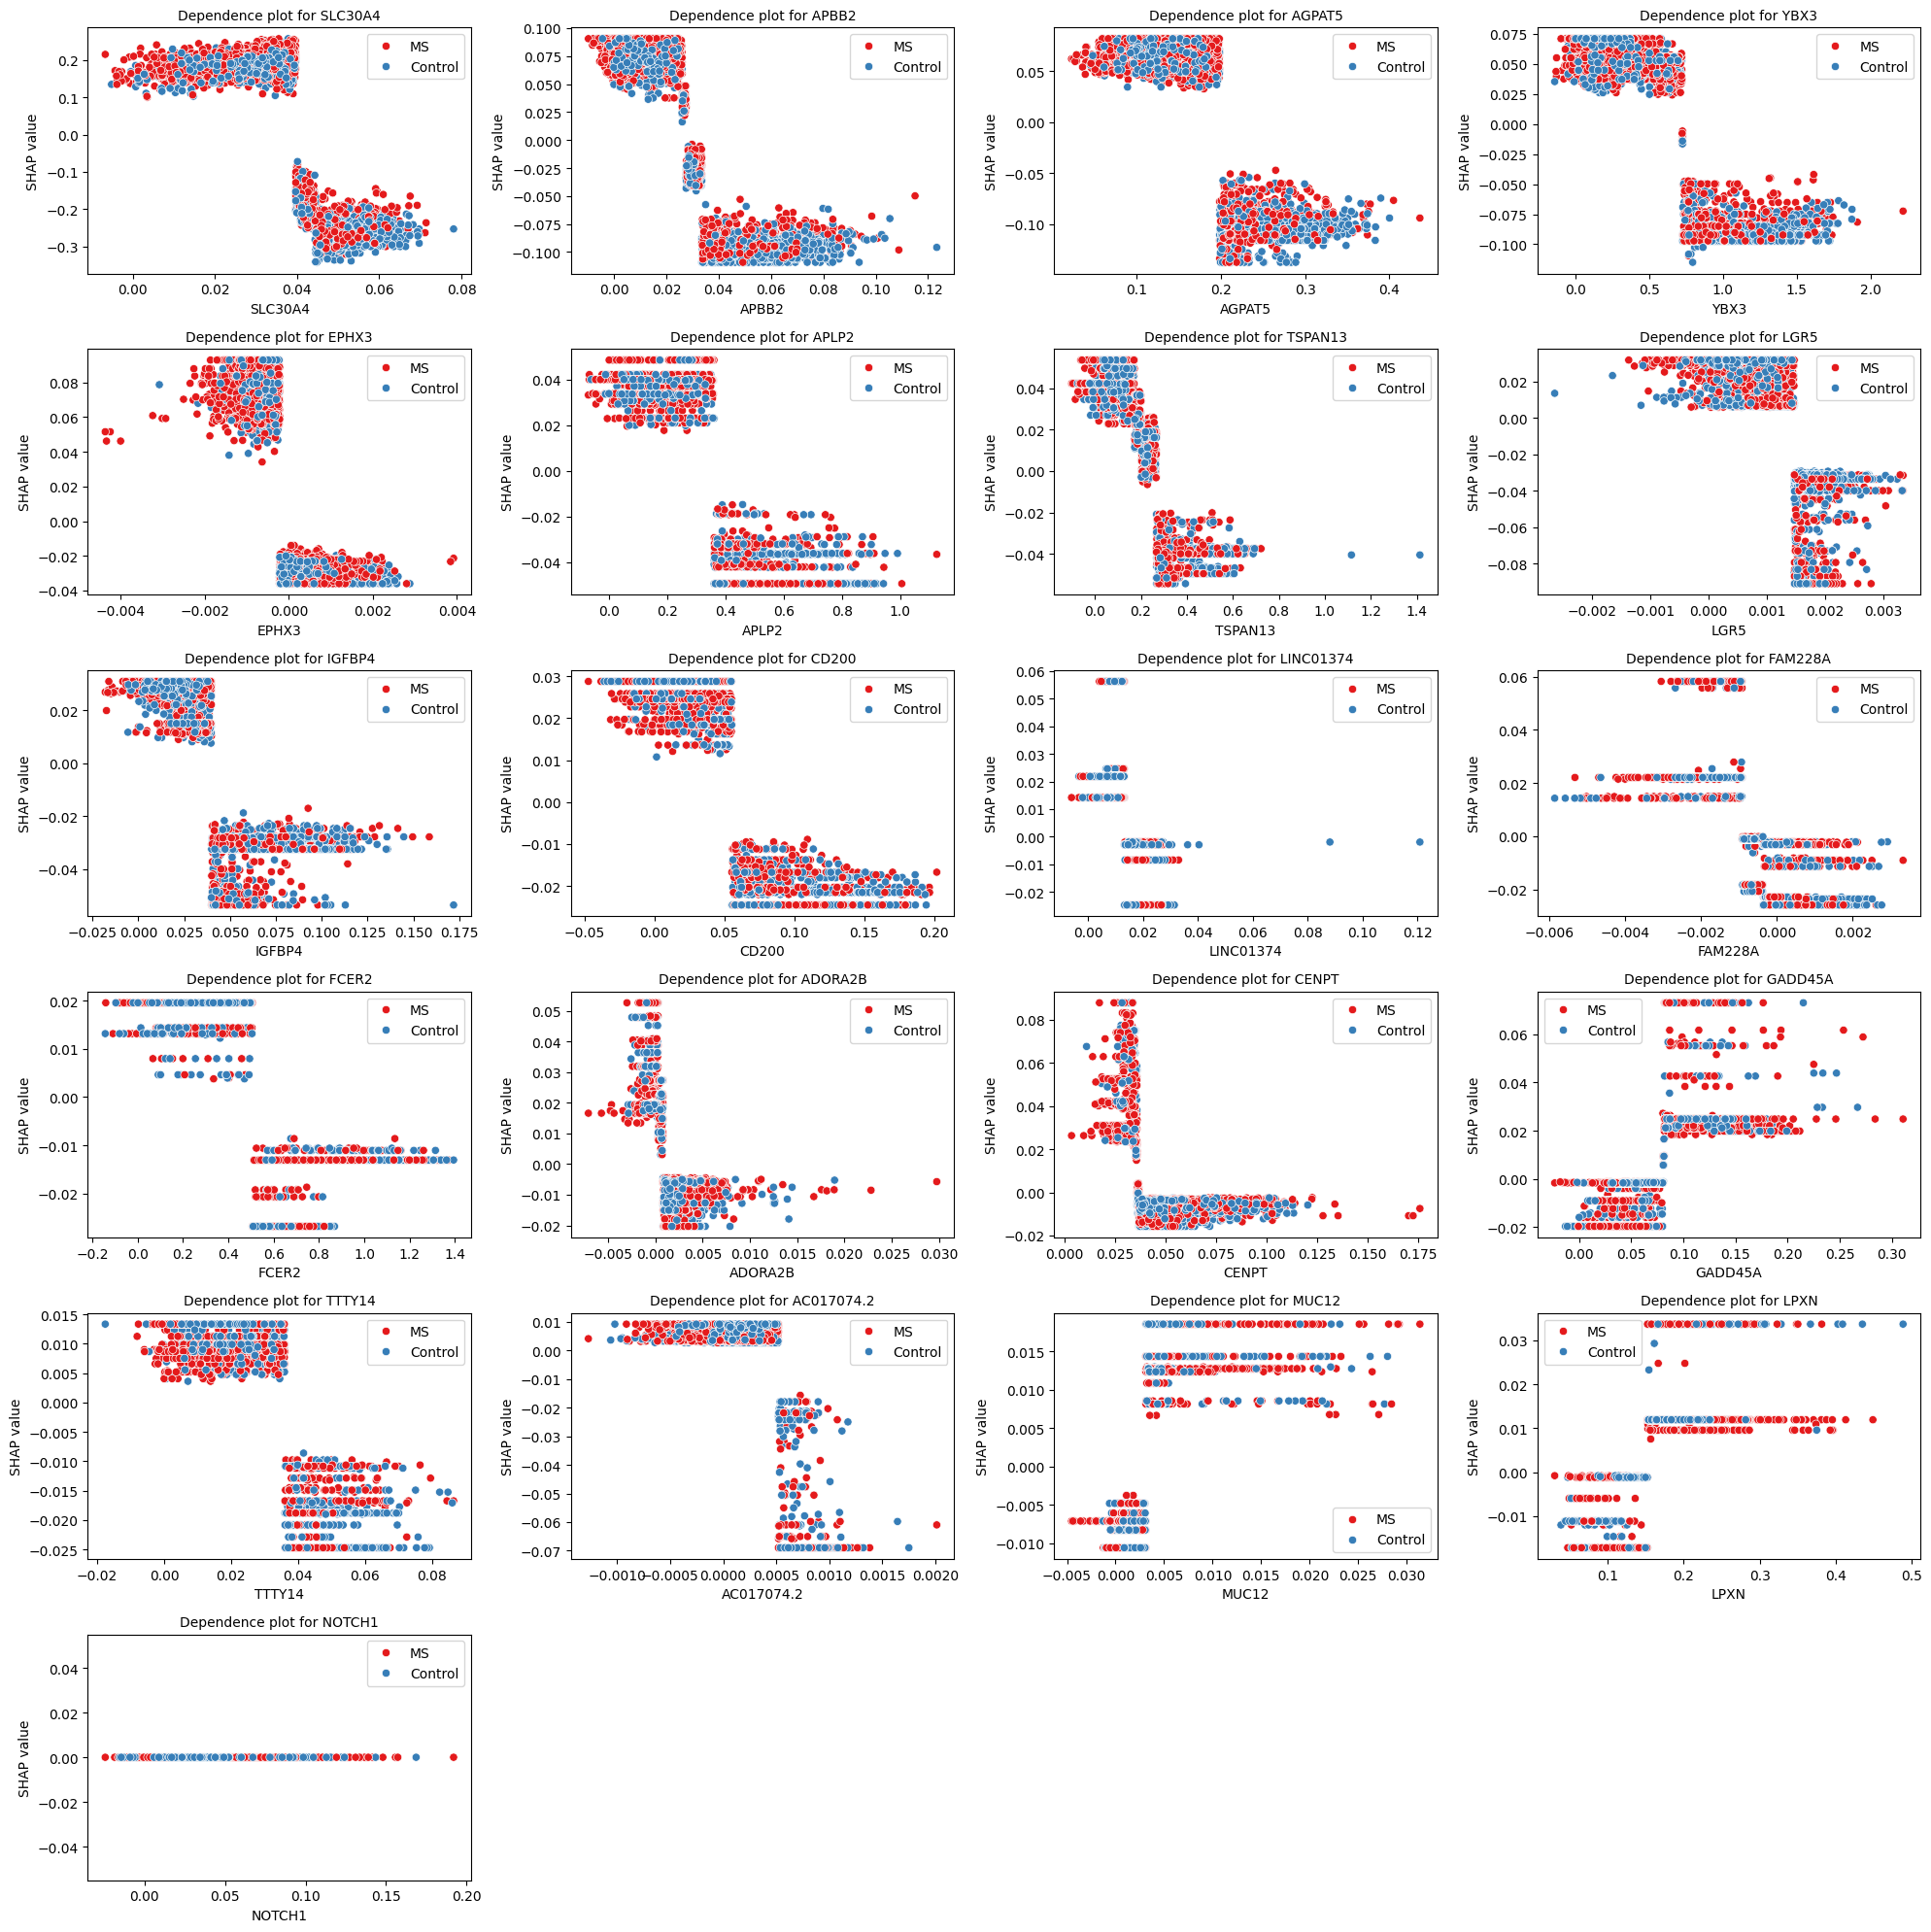

In [26]:
plt.close()

warnings.filterwarnings("ignore")

current = dataset_x

n = 6
fig, axes = plt.subplots(n, 4, figsize=(20, 20))
axes = axes.flatten() 

featureList = list(expl_sorted.keys())[:20]
featureList.append('NOTCH1')

for i, feature in enumerate(featureList):
    if i >= len(axes):
        break
    
    shap_vals = shap_object.values[:, current.columns.get_loc(feature)]
    feature_vals = current[feature].values

    customDf = pd.DataFrame({
        'SHAP': shap_vals,
        'Feature': feature_vals,
        'Label': ['MS' if value == "MS" else 'Control' for value in label]

    })

    sns.scatterplot(data=customDf, x='Feature', y='SHAP', hue='Label', palette='Set1', ax=axes[i])
    
    axes[i].set_title(f'Dependence plot for {feature}', fontsize=10)
    axes[i].set_xlabel(f'{feature}')
    axes[i].set_ylabel('SHAP value')
    axes[i].legend()

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<h3>Dependence plot with interactions beetween the combination of the first 5 features for importance</h3>

ValueError: Could not find feature named: SLC30A4

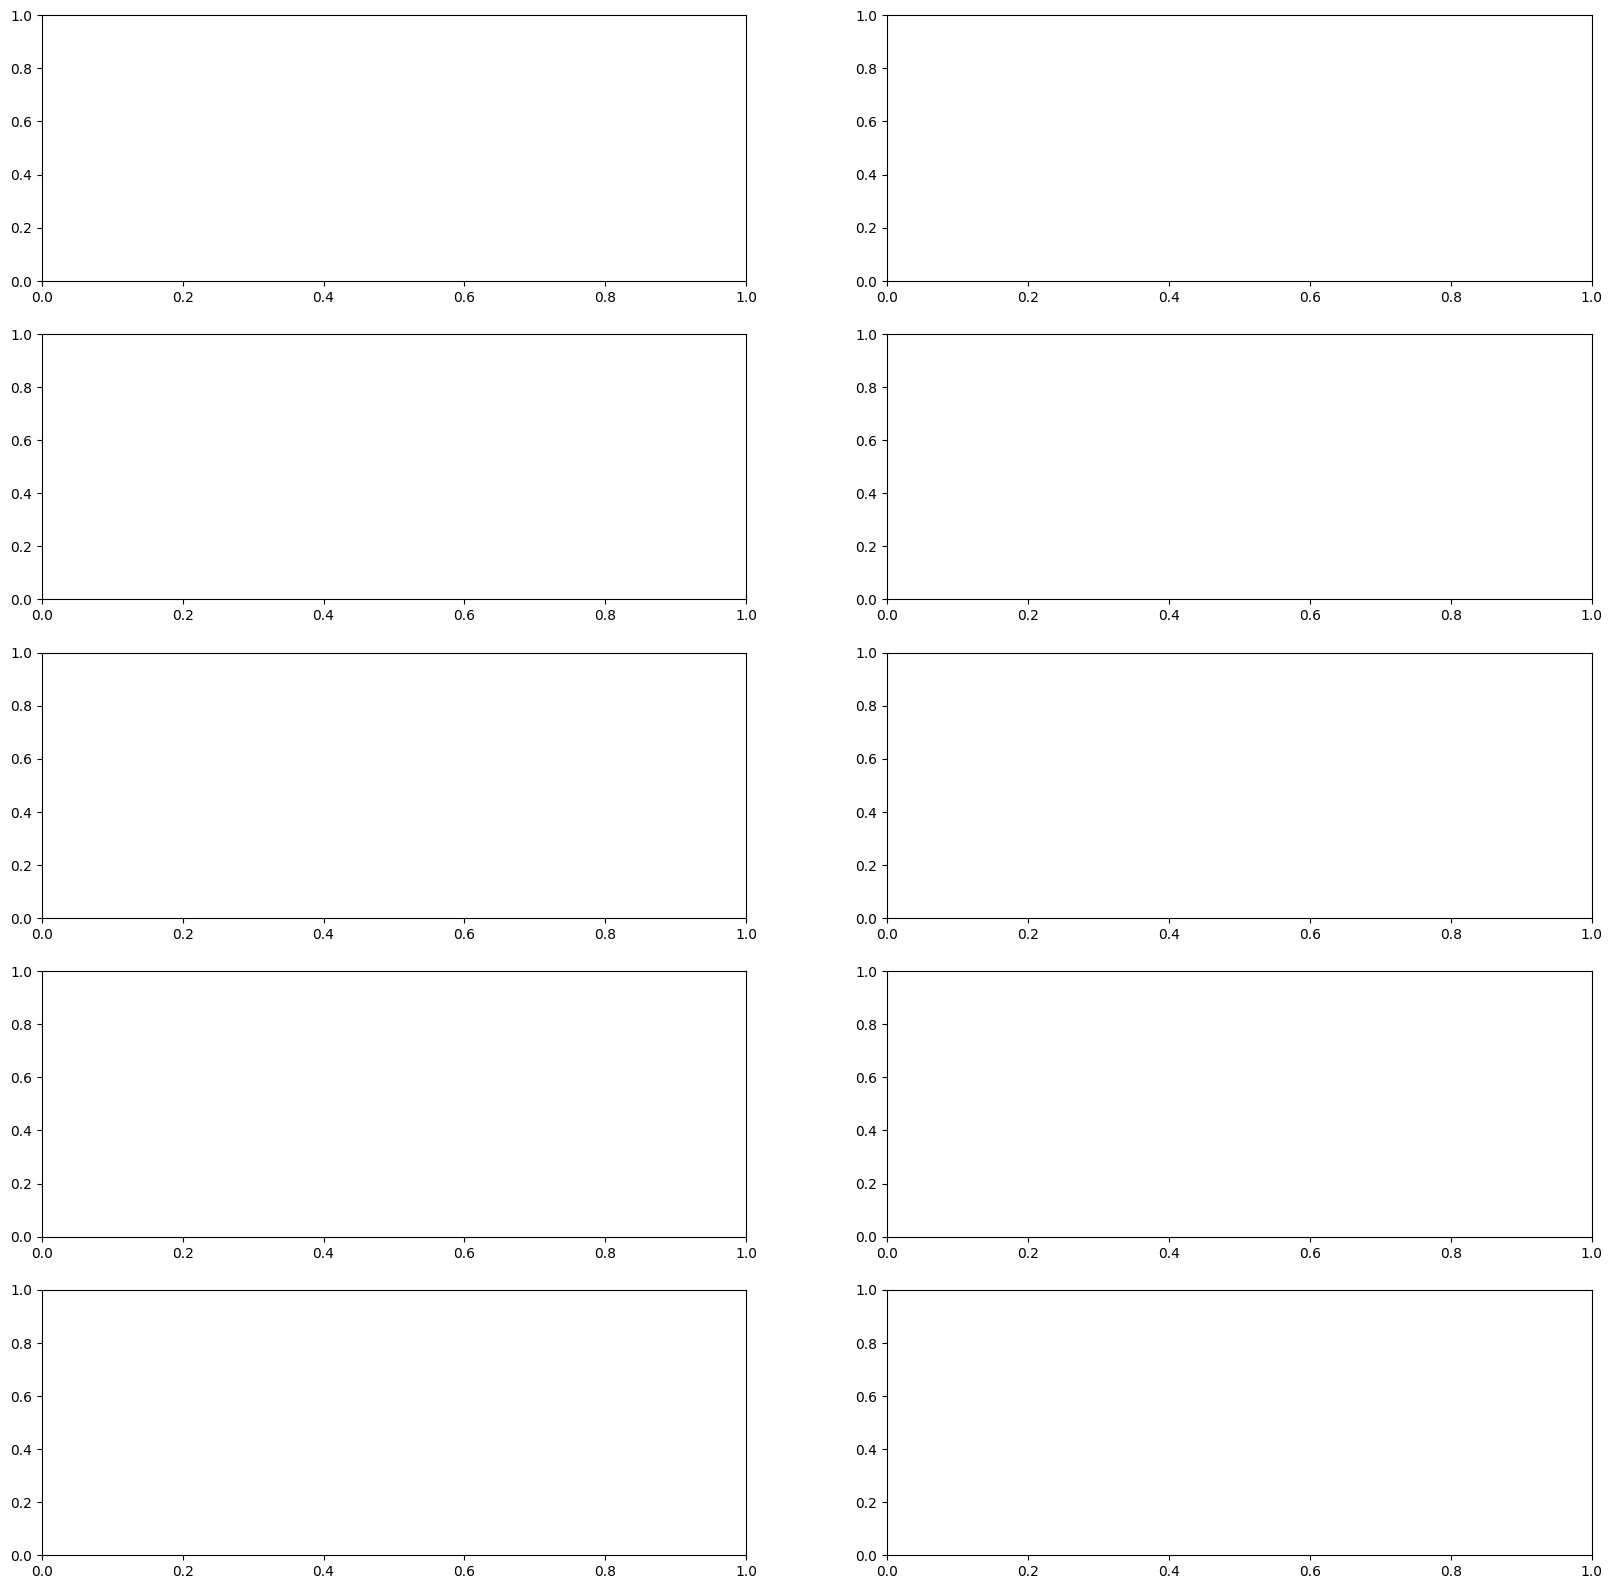

In [27]:
plt.close()

n = 5
fig, axes = plt.subplots(n, 2, figsize=(20, 20))
axes = axes.flatten()

features = list(expl_sorted.keys())[:5]
featuresCoupled = list(combinations(features, 2))

for i, feature in enumerate(featuresCoupled):
    if i >= len(axes): 
        break
    shap.dependence_plot(
        feature[0],
        shap_values,
        current_Scaled, 
        interaction_index=feature[1],
        ax=axes[i],
        alpha=1,
        show=False
    )
    
    axes[i].set_title(f'Dependence plot for {feature}', fontsize=10)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() 
plt.show()

<h3>Shap correlation between top genes</h3>

KeyboardInterrupt: 

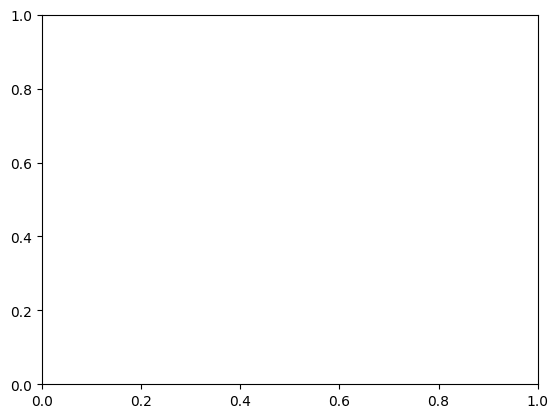

In [28]:
plt.close()
fig, ax = plt.subplots()
shap.plots.heatmap(shap_object, max_display=16, show=False, plot_width=20)
fig.subplots_adjust(left=0.3, top=0.9)
plt.title('Top 15 features for importance')
plt.show()

In [ ]:
shapCorr = pd.DataFrame(shap_object.values, columns=dataset.var_names)[list(expl_sorted.keys())].corr()

plt.figure(figsize=(15,10))
sns.heatmap(shapCorr, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matrice di Correlazione')
plt.show()

<h3>Insert ex clusters</h3>

In [ ]:
clusters = joblib.load("uniqueClusters.pkl")
clusters

In [ ]:
clusterEnriched = addGeneClusters(expl_sorted, joblib.load("uniqueClusters.pkl"))
feature_nonZeroEnriched = addGeneClusters(feature_nonZero, joblib.load("uniqueClusters.pkl"))

In [ ]:
joblib.dump(feature_nonZeroEnriched, 'pbmc_bcells_enriched.p')

<h3>SHAP vs DEA graph</h3>

In [32]:
import pandas as pd

# Load the CSV file into a Pandas DataFrame
dea_genes = pd.read_csv("../DEA/PBMC_BCELLS.csv")

# Sort the DataFrame by the 'p_val_adj' column in ascending order
sorted_dea_genes_df = dea_genes.sort_values(by="p_val_adj")

# Create a dictionary of gene: importance (p_val_adj)
gene_importance = dict(
    zip(sorted_dea_genes_df["Unnamed: 0"], sorted_dea_genes_df["p_val_adj"])
)

dea_genes = gene_importance

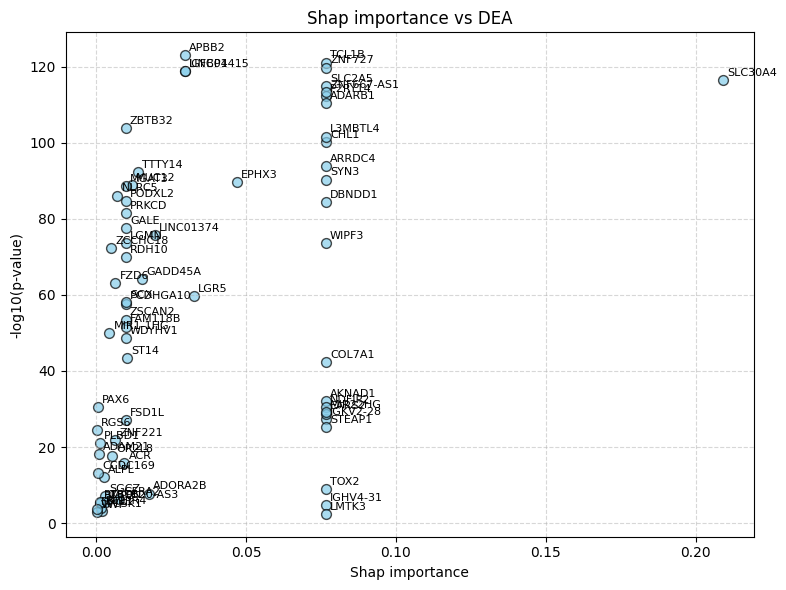

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text  # Import adjust_text

# Assuming clusterEnriched and dea_genes are already defined

point_x = []
point_y = []
labels = []
texts = [] # List to store text objects for adjust_text

for gene, value in clusterEnriched.items():
    if value > 0 and gene in dea_genes.keys():
        point_x.append(clusterEnriched[gene])
        point_y.append(-np.log10(dea_genes[gene]))
        labels.append(gene)

plt.figure(figsize=(8, 6))  # Adjusted figure size (smaller)

plt.scatter(
    point_x,
    point_y,
    color="skyblue",
    s=50,  # Reduced marker size
    edgecolors="black",
    alpha=0.7,
)

# Create annotations for each point
for i, label in enumerate(labels):
    t = plt.annotate(
        label,
        (point_x[i], point_y[i]),
        textcoords="offset points",
        xytext=(3, 3),  # Reduced offset
        ha="left",  # Align labels to the left
        fontsize=8,
        color="black",
    )
    texts.append(t)


plt.xlabel("Shap importance", fontsize=10)
plt.ylabel("-log10(p-value)", fontsize=10)
plt.title("Shap importance vs DEA", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


<h3>Venn diagram SHAP and DEA</h3>

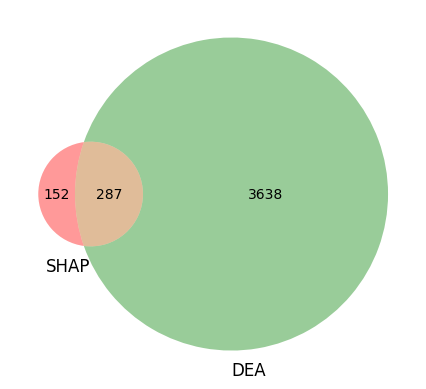

In [34]:
venn2(subsets = [set(feature_nonZeroEnriched), set(dea_genes.keys())], set_labels = ('SHAP', 'DEA'))
plt.show()

Feature important for SHAP not detected by DEA

In [35]:
print(len(set.difference(set(feature_nonZeroEnriched), set(dea_genes.keys()))), set.difference(set(feature_nonZeroEnriched), set(dea_genes.keys())))

152 {'CTDSPL', 'KRT10', 'LINC00582', 'FAM187B', 'MZB1', 'SERTAD4-AS1', 'C11orf80', 'SLC44A1', 'VDR', 'QPCTL', 'CHAC2', 'MEIS1', 'IL10RA', 'IHH', 'TM4SF18', 'FAM114A1', 'WFDC10B', 'GPNMB', 'IGKV3-11', 'HNRNPA0', 'CCNJ', 'SHBG', 'FTSJ1', 'LGALS4', 'FDX1', 'EDEM1', 'PIK3CG', 'UBA5', 'CTSZ', 'LARP1B', 'FOXD1', 'FKBP14', 'SLC17A9', 'AC009227.2', 'IGHV3-23', 'ATG4A', 'ALG5', 'HOXB2', 'STT3A', 'VPS37C', 'CD79B', 'SIL1', 'WARS', 'CCDC110', 'OXCT2', 'SAMSN1-AS1', 'TSC22D1', 'MARCH9', 'IGHV3-41', 'B4GALT3', 'NDUFAF1', 'DLX6-AS1', 'CENPT', 'ARHGAP25', 'AC017074.2', 'LPXN', 'NPIPA5', 'FAM228A', 'NCF4', 'SEL1L', 'C10orf88', 'LBX2', 'CNKSR1', 'ALDH1L2', 'EPN1', 'COL10A1', 'TBL2', 'ADAMDEC1', 'WT1-AS', 'INTS3', 'ZC3HAV1', 'PCAT14', 'TMED9', 'SEC14L1', 'PAOX', 'RRBP1', 'SYVN1', 'ZC2HC1B', 'IGKV1-17', 'ARF4', 'SMIM3', 'SLC6A9', 'SLC35B1', 'NAPA-AS1', 'TAL1', 'TRAM1', 'INAFM1', 'CNP', 'CD37', 'USO1', 'ENAM', 'ARHGAP42', 'BCKDK', 'IGKV3-20', 'IGLJ1', 'IGHV3OR16-10', 'ANKRD16', 'FAM186A', 'MAGEB2', 'SAR1B

Best 300 SHAP features compared with DEA

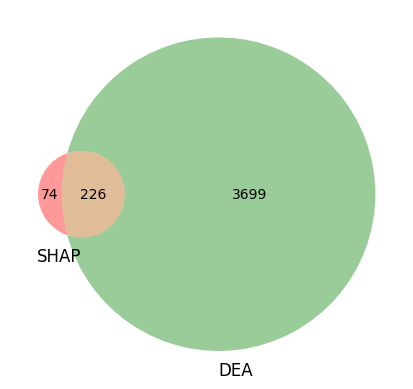

In [36]:
venn2(subsets = [set(list(feature_nonZeroEnriched.keys())[:300]), set(dea_genes.keys())], set_labels = ('SHAP', 'DEA'))
plt.show()

Known feature important for MS

In [37]:
limit = None

feature_nonZeroList = list(feature_nonZero.keys())[:limit]

for gene in ["GABPA", "CTCF", "EGR1", "YY1", "SPI1", "CLOCK", "ARNTL", "BACH1", "GFI1", "IFNB1", "MOG",  "MBP", "CD42", "IFNG", "IL17A", "IL10", "TNF", "IL1B", "IL6", "TNFRSF1A", "CYP27B1", "IL7R", "HLA-DRB1", "HLA-DRB5", "IL2RA"]:
    if gene in list(feature_nonZeroEnriched.keys())[:limit] and gene in list(dea_genes.keys())[:limit]:
        print(gene, "Both")
    elif gene in list(feature_nonZeroEnriched.keys())[:limit]:
        print(gene, "SHAP")
    elif gene in list(dea_genes.keys())[:limit]:
        print(gene, "DEA")
    else:
        print(gene, "None")

GABPA None
CTCF None
EGR1 DEA
YY1 None
SPI1 None
CLOCK None
ARNTL None
BACH1 None
GFI1 None
IFNB1 None
MOG DEA
MBP None
CD42 None
IFNG None
IL17A None
IL10 DEA
TNF DEA
IL1B None
IL6 None
TNFRSF1A None
CYP27B1 None
IL7R DEA
HLA-DRB1 None
HLA-DRB5 None
IL2RA DEA


In [38]:
import csv

# Get all unique genes from both dictionaries
all_genes = dataset.var_names

# Create list to store results
results = []

for gene in all_genes:
    in_enriched = gene in feature_nonZeroEnriched
    in_dea = gene in dea_genes
    
    if in_enriched and in_dea:
        category = "Both"
    elif in_enriched:
        category = "SHAP"
    elif in_dea:
        category = "DEA"
    else:
        category = "None"
    
    results.append({'Gene': gene, 'Category': category})

# Sort by gene name for easier viewing
results.sort(key=lambda x: x['Gene'])

# Write to CSV
csv_filename = 'gene_BCELLS_PBMC.csv'
with open(csv_filename, 'w', newline='') as csvfile:
    fieldnames = ['Gene', 'Category']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    writer.writerows(results)

print(f"CSV file created: {csv_filename}")
print(f"Total genes analyzed: {len(results)}")
print(f"\nCategory breakdown:")
print(f"SHAP only: {sum(1 for r in results if r['Category'] == 'SHAP')}")
print(f"DEA only: {sum(1 for r in results if r['Category'] == 'DEA')}")
print(f"Both: {sum(1 for r in results if r['Category'] == 'Both')}")
print(f"None: {sum(1 for r in results if r['Category'] == 'None')}")


CSV file created: gene_BCELLS_PBMC.csv
Total genes analyzed: 17410

Category breakdown:
SHAP only: 113
DEA only: 3292
Both: 178
None: 13827


In [19]:
print(list(feature_nonZeroEnriched.keys()))

['SLC30A4', 'APBB2', 'CAMK2D', 'SNX29', 'CORO2B', 'RRM2B', 'RAB30', 'IGHD', 'IGHM', 'FCRL1', 'AGPAT5', 'TPST1', 'DSP', 'YBX3', 'L3MBTL4', 'MMP17', 'TAPT1', 'TCL1A', 'APLP2', 'NSUN7', 'BACH2', 'LIX1', 'CLCN4', 'CD200', 'EPB41L2', 'TCL1B', 'ABCB4', 'CDCA7L', 'IL4R', 'FCER2', 'TSPAN13', 'FAM111B', 'BCL7A', 'ZDHHC19', 'DBNDD1', 'ZNF318', 'AL132709.8', 'SERPINB9P1', 'P2RY14', 'ADARB1', 'PDE7B', 'ZHX3', 'MACROD2', 'DTX4', 'MSMP', 'NETO1', 'SYT17', 'COL19A1', 'LINC01104', 'TCTN1', 'ZNF667-AS1', 'ARHGAP32', 'EPHX3', 'LGR5', 'IGFBP4', 'LINC01415', 'LINC01374', 'FAM228A', 'ADORA2B', 'CENPT', 'GADD45A', 'TTTY14', 'AC017074.2', 'MUC12', 'LPXN', 'ST14', 'STAMBPL1', 'PNMA5', 'TFEC', 'SIGLEC6', 'ACAP3', 'DGKG', 'ACR', 'IHH', 'IFNGR2', 'CD37', 'MLEC', 'ENPP7', 'PDXK', 'SPACA3', 'TMEM39A', 'PARM1', 'C1orf53', 'NEU1', 'PRDM1', 'ZC2HC1B', 'TRAM2', 'IGHV3-7', 'SIX5', 'GMPPB', 'FDX1', 'PREB', 'SLC12A4', 'ARF4', 'NDUFAF1', 'PERP', 'SLC39A7', 'LBX2', 'CCR10', 'P4HB', 'CLPTM1L', 'LARP1B', 'SLC52A2', 'KCNK6', 

In [20]:
cumulativeImportance = (np.array(list(feature_nonZero.values())).cumsum() / np.array(list(feature_nonZero.values())).sum()) * 100
index_80_percent = np.where(cumulativeImportance >= 80)[0][0] + 1
index_80_percent


25

In [27]:
len(feature_nonZeroEnriched)

439